In [124]:
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.table import Table

table = fits.open('cb19/cb2019_z0100_chab_hr_xmilesi_ssp.fits')
my_table = Table(table[1].data)

# Extract the names of the columns
colnames = my_table.colnames

ages = np.array([float(name.replace('p', '.').replace('E0', 'e0')[1:]) for name in colnames[1:]])
wavelength = np.array(my_table['Wavelength'])

In [158]:
mettalicities = np.array([0.0000, 0.0001, 0.0002, 0.0005, 0.0010, 0.0020, 0.0040, 
                 0.0060, 0.0080, 0.0100, 0.0140, 0.0170, 0.0200, 0.0300, 
                 0.0400, 0.0600])

loadedTables = {}

def getFITSFile(metallicity):
    if(metallicity in loadedTables):
        df = loadedTables[metallicity]
        return df

    metStr = f'{metallicity:0.4f}'[2:]
    filename = f'cb19/cb2019_z{metStr}_chab_hr_xmilesi_ssp.fits'
    table = fits.open(filename)
    my_table = Table(table[1].data)
    colnames = my_table.colnames

    df = np.zeros([len(my_table[colnames[0]]), len(colnames)])
    for col in range(len(colnames)):
        df[:,col] = my_table[colnames[col]]

    loadedTables[metallicity] = df

    return df

def findIndex(value, list):
    '''
    (double, ndarray) -> int

    Esse método recebe um número decimal e retorna, 
    pelo método da bissecção, o índice com o valor
    mais próximo à esse número em nossa tabela 
    (arredondando o valor para baixo)  
    '''
    
    low = 0 # Índice do menor elemento do intervalo da busca
    high = list.size - 1 # Índice do maior elemento

    # Caso o valor de entrada seja maior ou igual que o valor do maior elemento 
    # da tabela, retornamos o índice deste elemento
    if(value >= list[high]): return high

    # Realiza a bissecção dos índices até que o intervalo da bissecção tenha tamanho 1
    while(high - low > 1):
        middle = int((low + high) / 2) # Cálculo do valor do índice do meio (bissecção) do intervalo
        
        if(list[middle] > value): high = middle
        else: low = middle

    return min(low, len(list) - 2) # Retorna o menor índice encontrado

def interpolate(value, list):
    '''
    (double, ndarray) -> double

    Esse método recebe um número decimal e retorna o valor
    interpolado linearmente entre os dois valores mais próximos 
    à esse número em nossa tabela  
    '''

    low = max(findIndex(value, list), 0)
    high = min(low + 1, len(list) - 1)

    lowerValue = getFITSFile(list[low])[:, 1:] # Exclui a coluna do comprimento de onda
    higherValue = getFITSFile(list[high])[:, 1:]

    # Realiza a interpolação linear entre os dois valores mais próximos
    slope = (value - list[low]) / (list[high] - list[low])

    return (1 - slope) * lowerValue + slope * higherValue

In [ ]:
# Modelos de Atenuação de Poeira (usando Salim)

def calzetti_obscuration_raw(lambda_nm):
    """
    Calcula a curva de obscurecimento de Calzetti et al. (2000) (NÃO normalizada).
    Retorna k'(lambda).
    """
    lambda_um = lambda_nm / 1000.0
    k_raw = np.zeros_like(lambda_um)
    R_V_calzetti = 4.05
    
    # Faixa UV (0.12 <= lambda < 0.63 µm)
    uv_mask = (lambda_um >= 0.12) & (lambda_um < 0.63)
    x_uv = lambda_um[uv_mask]
    k_raw[uv_mask] = 2.659 * (-2.156 + (1.509 / x_uv) - (0.198 / x_uv**2) + (0.011 / x_uv**3)) + R_V_calzetti
    
    # Faixa Óptica/NIR (0.63 <= lambda <= 2.2 µm)
    opt_mask = (lambda_um >= 0.63) & (lambda_um <= 2.2)
    x_opt = lambda_um[opt_mask]
    k_raw[opt_mask] = 2.659 * (-1.857 + 1.040 / x_opt) + R_V_calzetti
    
    #k_raw[(lambda_um < 0.12) | (lambda_um > 2.2)] = np.nan
    return k_raw

def drude_profile_nm(lambda_nm):
    """
    Perfil Drude para o "bump" de 2175 Å (0.2175 µm).
    """
    x0 = 4.595 # 1 / 0.2175 µm
    gamma = 1.0 # µm^-1
    x = 1000.0 / lambda_nm # em µm^-1
    return x**2 / ((x**2 - x0**2)**2 + x**2 * gamma**2)

def salim_attenuation(lambda_nm, delta=-0.2, B=1.0):
    """
    Calcula a curva de atenuação de Salim et al. (2018).
    """
    Rv_mod = 3.1
    Rv_cal = 4.05
    
    k_cal = calzetti_obscuration_raw(lambda_nm)
    D_lambda = drude_profile_nm(lambda_nm)
    
    # Equação de Salim
    k_mod = k_cal * (lambda_nm / 550.0)**delta + B * D_lambda * (Rv_mod / Rv_cal)
    
    # Re-normaliza a curva para ter valor 1 em 550 nm para comparação
    k_cal_550 = calzetti_obscuration_raw(np.array([550.0]))
    D_lambda_550 = drude_profile_nm(np.array([550.0]))
    norm_factor = k_cal_550 + B * D_lambda_550 * (Rv_mod / Rv_cal)
    
    return k_mod / norm_factor

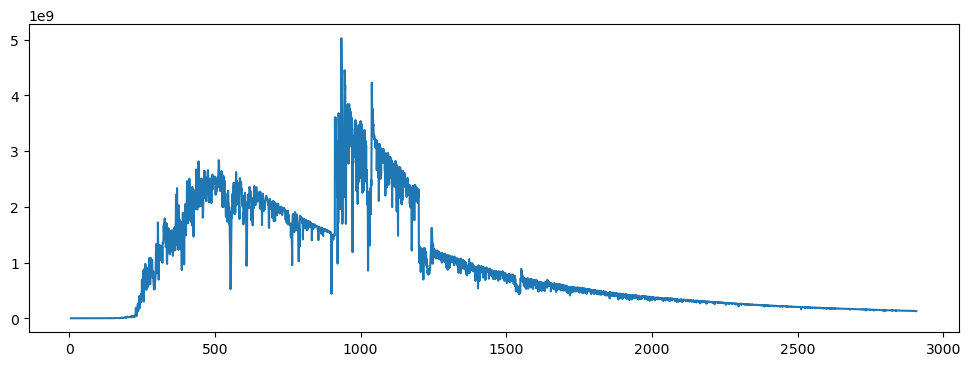

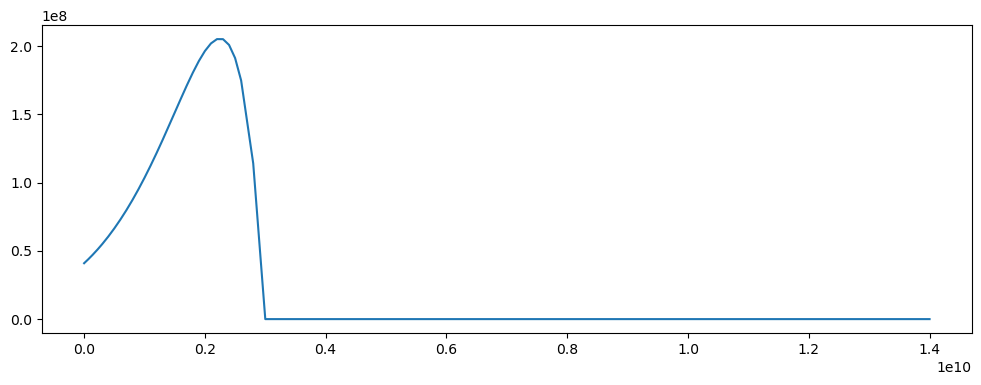

In [198]:
z_sol = 0.02
metallicity = 0.5 * z_sol

spectrum = interpolate(metallicity, mettalicities) # Pega o espectro para a metalicidade interpolada

# Colocamos a atenuação de poeira antes da soma dos espectros
av = 0.2           # Absolute attenuation in the V band: magnitudes
eta = 1.           # Multiplicative factor on Av for stars in birth clouds

delta = 0.         # Deviation from Calzetti slope ("Salim" type only)
B = 0.             # 2175A bump strength ("Salim" type only)

k_lambda = salim_attenuation(wavelength * 0.1, delta, B)

# Converter k(lambda) e Av para Profundidade Óptica (Tau)
# A_lambda = Av * k_lambda
# Tau_lambda = A_lambda / 1.086
tau_lambda_ISM = (av * k_lambda) / 1.086
tau_lambda_ISM = tau_lambda_ISM[:, np.newaxis] # Transforma em matriz coluna

tau_matrix = np.tile(tau_lambda_ISM, (1, len(ages)))

young_mask = ages < 1e7
tau_matrix[:, young_mask] *= eta

spectrum_dusted = spectrum * np.exp(-tau_matrix)

# Delayed Tau model
tau = 0.75e9 # Tempo de escala de formação estelar (decaimento da função) em anos
age = 3e9 # A estrela nasceu em (age - t)
massformed = 10e9 # Massa total formada em estrelas ao longo da vida da galáxia em Msun

time_since_formation = age - ages # A estrela nasceu em (age - t)
sfh = (time_since_formation * np.exp(-time_since_formation / tau)).clip(0)

# Normalização para 1 Msun
if np.sum(sfh) > 0:
    sfh = sfh / np.sum(sfh)

sfh = sfh * massformed

# Obtemos o espectro final
finalSpectra = spectrum_dusted @ sfh
plt.figure(figsize=(12,4))
plt.plot(wavelength[:5000], finalSpectra[:5000])
plt.show()

plt.figure(figsize=(12,4))
plt.plot(ages, sfh)
plt.show()